# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

# EDA

In [13]:
print("Info Dataset:")
print(df.info())
print("\nStatistik Dasar:")
df.describe()

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Distribusi Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


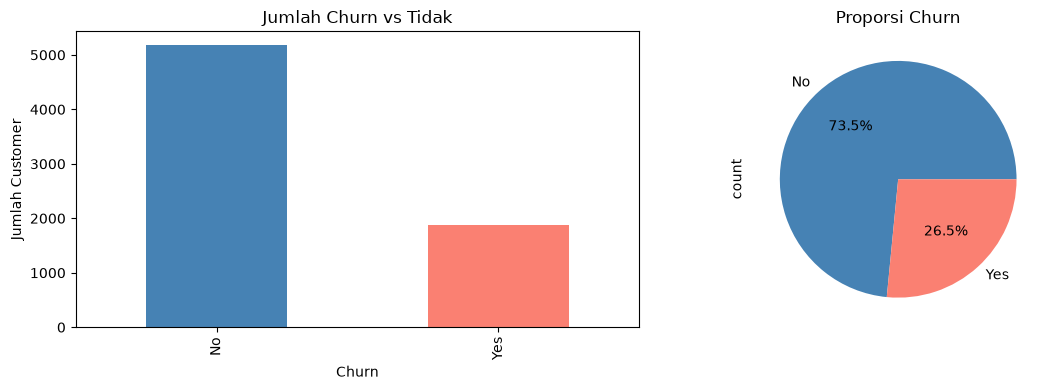

In [7]:
churn_count = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Distribusi Churn:")
print(churn_count)
print("\nPersentase:")
print(churn_pct.round(2))

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_count.plot(kind='bar', ax=ax[0], color=['steelblue', 'salmon'])
ax[0].set_title('Jumlah Churn vs Tidak')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Jumlah Customer')

# Pie chart
churn_count.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                 colors=['steelblue', 'salmon'])
ax[1].set_title('Proporsi Churn')

plt.tight_layout()
plt.savefig('../figures/churn_distribution.png', dpi=150)
plt.show()

In [9]:
# Cek kenapa TotalCharges jadi object
print(df['TotalCharges'].unique()[:20])

# Fix: convert ke numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Cek missing values setelah convert
print("\nMissing TotalCharges:", df['TotalCharges'].isnull().sum())

# Lihat row yang bermasalah
print(df[df['TotalCharges'].isnull()])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Missing TotalCharges: 11
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE 

In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [14]:
# Pisahkan kolom kategorikal dan numerikal
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')  # hapus ID, tidak relevan

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("=" * 50)
print("CATEGORICAL FEATURES - UNIQUE VALUES")
print("=" * 50)

for col in categorical_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().to_string())
    print("-" * 30)

CATEGORICAL FEATURES - UNIQUE VALUES

gender (2 unique):
gender
Male      3555
Female    3488
------------------------------

Partner (2 unique):
Partner
No     3641
Yes    3402
------------------------------

Dependents (2 unique):
Dependents
No     4933
Yes    2110
------------------------------

PhoneService (2 unique):
PhoneService
Yes    6361
No      682
------------------------------

MultipleLines (3 unique):
MultipleLines
No                  3390
Yes                 2971
No phone service     682
------------------------------

InternetService (3 unique):
InternetService
Fiber optic    3096
DSL            2421
No             1526
------------------------------

OnlineSecurity (3 unique):
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
------------------------------

OnlineBackup (3 unique):
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
------------------------------

DeviceProte

In [17]:
df.duplicated().sum()

0

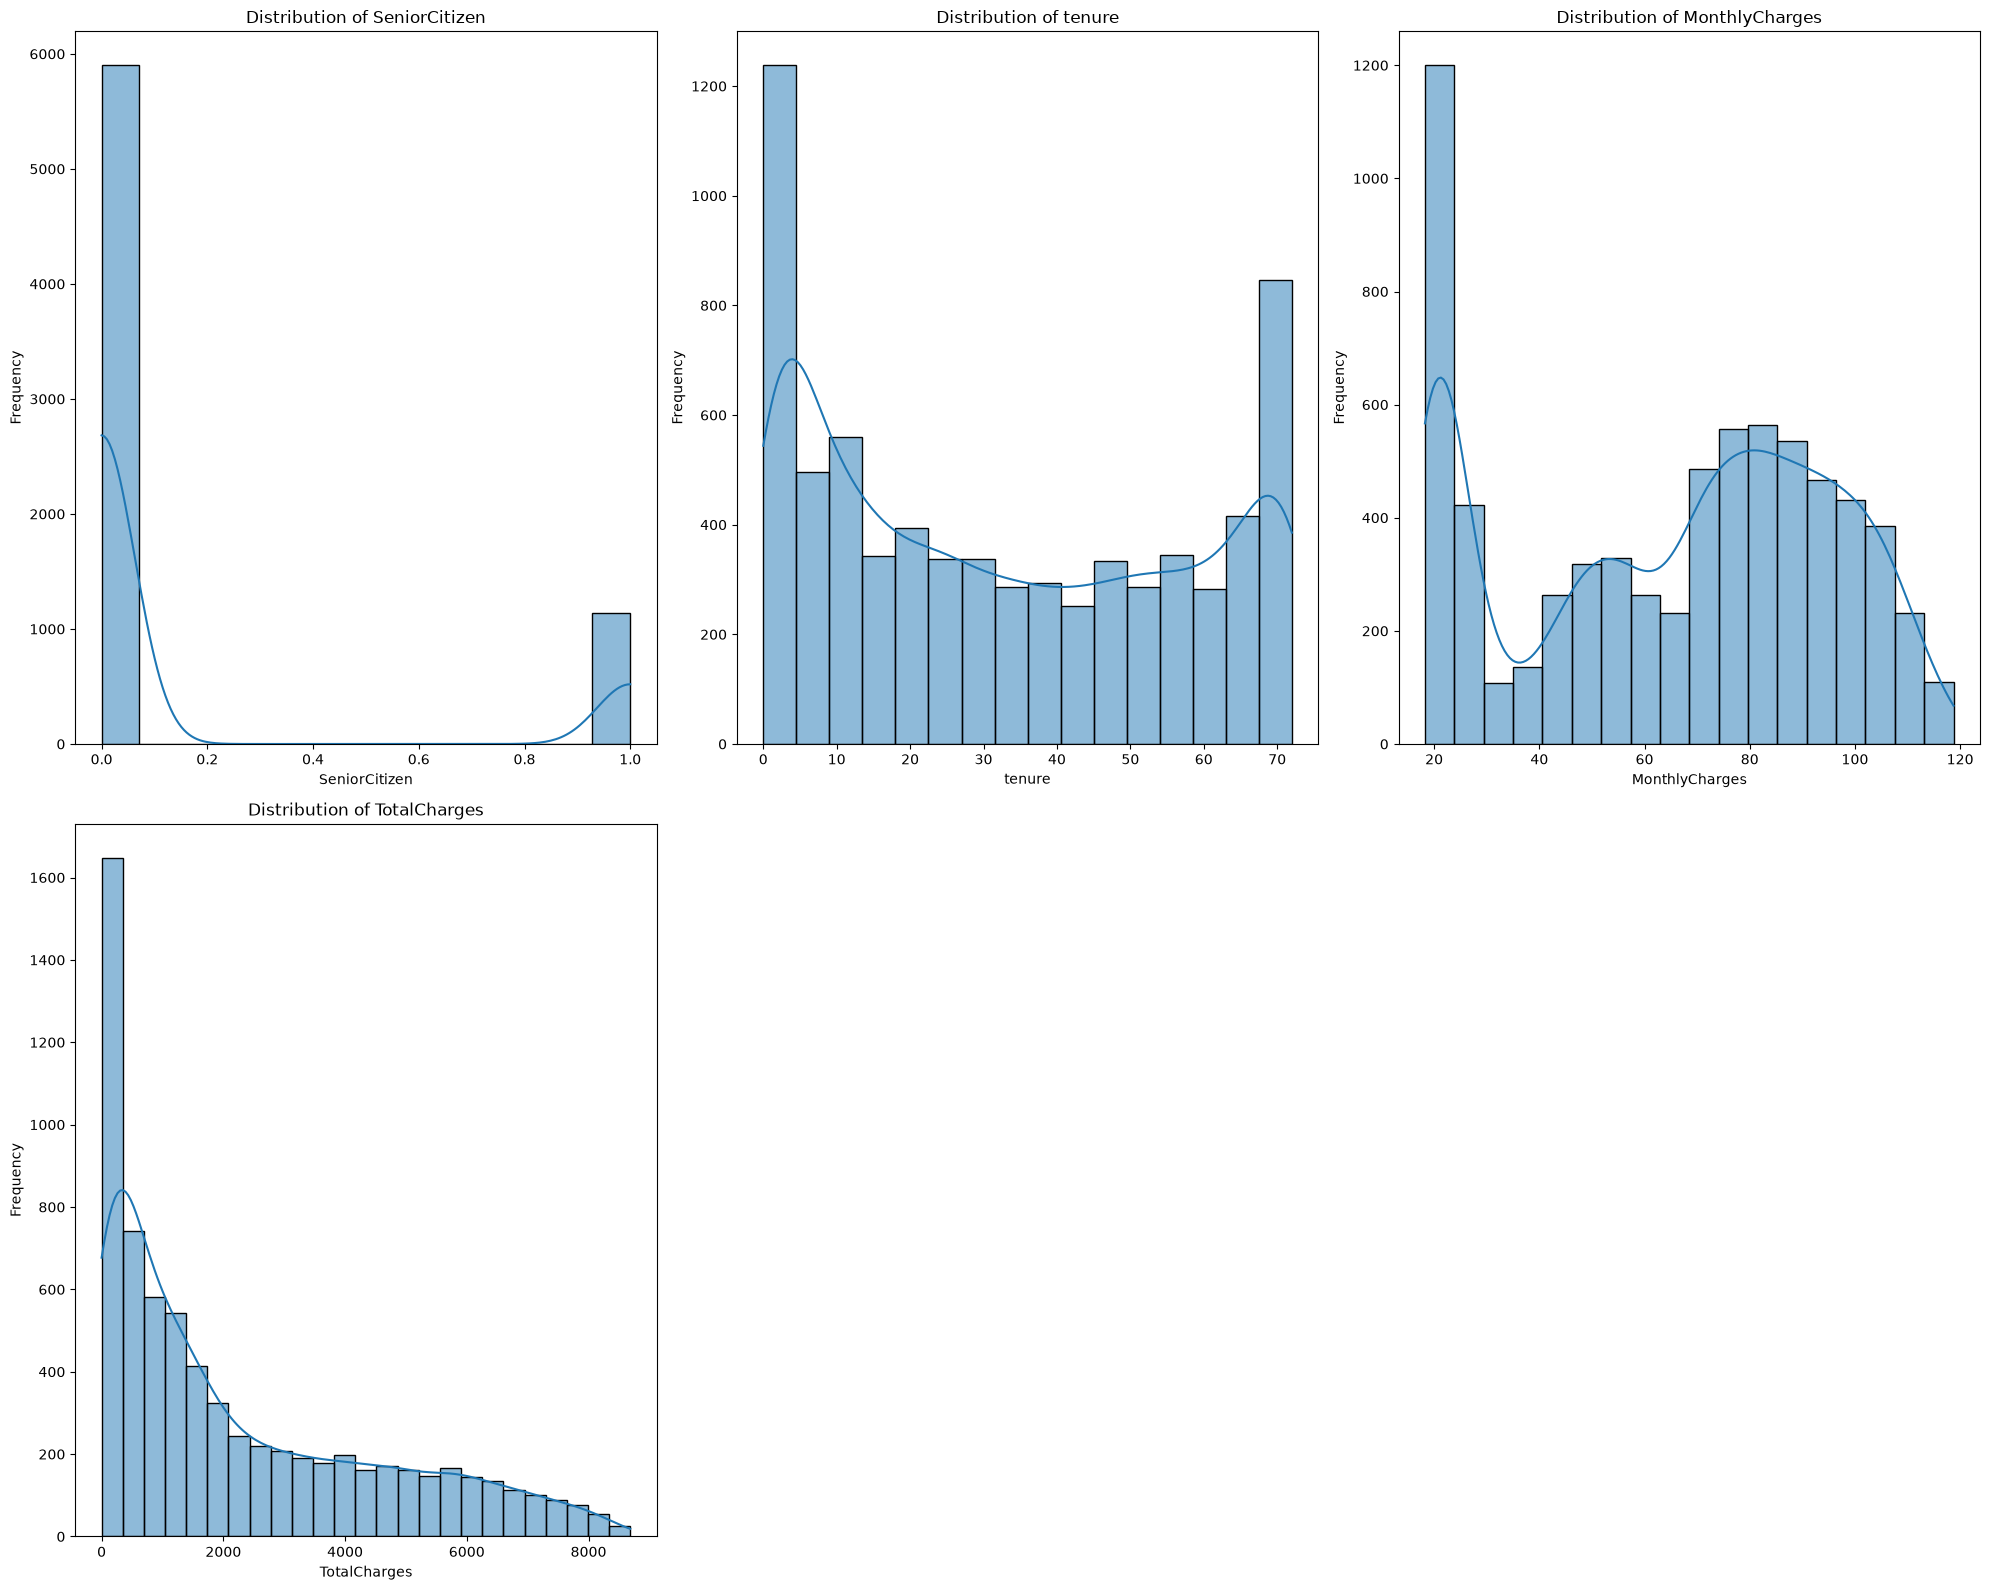

In [19]:
numerical_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(20, 16))

for i, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols)+2)//3, 3, i+1)

    sns.histplot(df[col].dropna(), kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/numerical_distribution.png', dpi=150)
plt.show()